# Predictability Score Example: Gold OHLC

This notebook demonstrates how to evaluate the predictive quality of financial time series using `predictability-score`.

Dataset:

- Gold OHLC prices
- Time ordered observations
- Example timeframe: 5-30 minutes

The objective is not to predict price directly.

Instead, we evaluate whether transformed financial signals contain exploitable temporal structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from predictability_score import     PredictabilityScore


In [3]:
df = pd.read_csv(
    "XAUUSD_M5.csv"
)

df.head()

,open,high,low,close
0,1186.94,1187.15,1186.04,1186.13
1,1186.10,1186.53,1186.08,1186.40
2,1186.40,1186.40,1185.52,1185.64
3,1185.57,1185.57,1184.67,1184.95
4,1184.97,1185.14,1184.82,1185.06
...,...,...,...,...
607288,2065.79,2065.84,2065.08,2065.52
607289,2065.53,2065.69,2065.26,2065.61
607290,2065.59,2065.62,2063.87,2064.31
607291,2064.32,2064.50,2063.22,2063.61


In [4]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607293 entries, 0 to 607292
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   open    607293 non-null  float64
 1   high    607293 non-null  float64
 2   low     607293 non-null  float64
 3   close   607293 non-null  float64
dtypes: float64(4)
memory usage: 18.5 MB


open     0
high     0
low      0
close    0
dtype: int64

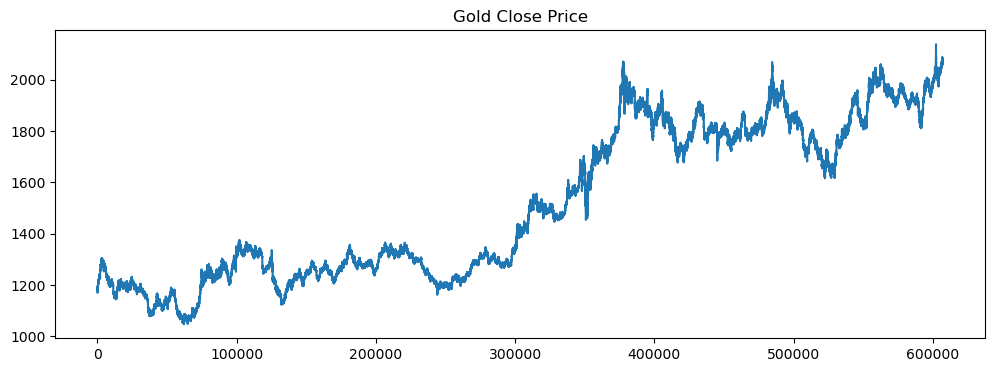

In [5]:
plt.figure(
    figsize=(12,4)
)

plt.plot(
    df["close"]
)

plt.title(
    "Gold Close Price"
)

plt.show()

In [6]:
df["log_return"] = (

    np.log(
        df["close"]
        /
        df["close"].shift(1)
    )

)


returns = (

    df["log_return"]

    .dropna()

    .values

)

In [7]:
evaluator = PredictabilityScore()


result = evaluator.evaluate(
    returns[-5000:]
)


result.total_score

54.762611974717856

In [8]:
df["Y_H"] = np.log(
    df["high"]
    /
    df["open"]
)


df["Y_L"] = np.log(
    df["low"]
    /
    df["open"]
)



df["Range"] = (

    np.log(
        df["high"]
        /
        df["low"]
    )

)

In [9]:
yh = (

    df["Y_H"]

    .dropna()

    .values

)


result_yh = evaluator.evaluate(
    yh[-5000:]
)


result_yh.total_score

54.318000961182925

In [10]:
yl = (

    df["Y_L"]

    .dropna()

    .values

)


result_yl = evaluator.evaluate(
    yl[-5000:]
)


result_yl.total_score

53.97756827744382

In [14]:
def show_result(result):

    print("Predictability Score")
    print("====================")
    
    print(f"Total Score       : {result.total_score:.2f}")
    print()
    
    print("Components")
    print("----------")
    
    print(f"Stationarity      : {result.stationarity:.2f}")
    print(f"Temporal          : {result.temporal:.2f}")
    print(f"Forecastability   : {result.forecastability:.2f}")
    print(f"Null Significance : {result.null_significance:.2f}")
    print(f"Stability         : {result.stability:.2f}")
    
show_result(result)
show_result(result_yh)
show_result(result_yl)

Predictability Score
Total Score       : 54.76

Components
----------
Stationarity      : 100.00
Temporal          : 47.34
Forecastability   : 0.00
Null Significance : 100.00
Stability         : 79.28
Predictability Score
Total Score       : 54.32

Components
----------
Stationarity      : 65.00
Temporal          : 56.90
Forecastability   : 10.00
Null Significance : 100.00
Stability         : 90.93
Predictability Score
Total Score       : 53.98

Components
----------
Stationarity      : 65.00
Temporal          : 59.07
Forecastability   : 5.24
Null Significance : 100.00
Stability         : 96.38


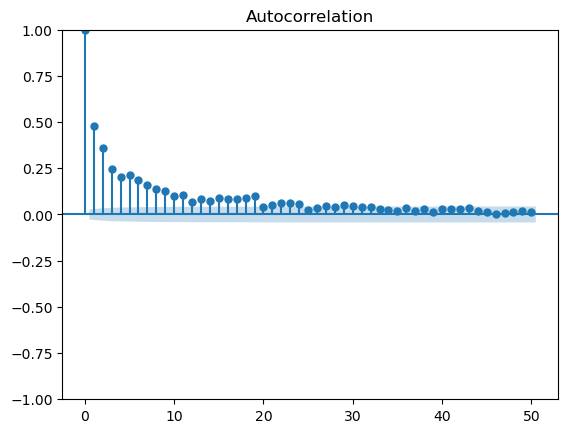

In [12]:
from statsmodels.graphics.tsaplots import plot_acf


plot_acf(
    yh[-5000:],
    lags=50
)

plt.show()

In [15]:
from predictability_score.forecast import (
    TensorFlowBackend
)

ImportError: cannot import name 'TensorFlowBackend' from 'predictability_score.forecast' (C:\Users\jalal\Desktop\algo lab\Conformal Prediction\TS Predictability_Score\predictability_score\forecast\__init__.py)

In [16]:
backend = TensorFlowBackend(

    window=64,

    epochs=20

)


model = PredictabilityScore(

    forecast_backend=backend

)


result_lstm = model.evaluate(
    yh
)


result_lstm.total_score

NameError: name 'TensorFlowBackend' is not defined

In [17]:
scores = {

    "Close Return":
        result.total_score,

    "High/Open":
        result_yh.total_score,

    "Low/Open":
        result_yl.total_score

}


pd.Series(
    scores
).sort_values(
    ascending=False
)

Close Return    54.762612
High/Open       54.318001
Low/Open        53.977568
dtype: float64

## Interpretation

A higher Predictability Score means:

- stronger statistical structure
- higher temporal dependency
- better model extractability
- more stable behavior


It does not mean:

- guaranteed profit
- future price certainty
- absence of market regime changes


For financial modeling, the recommended workflow is:

OHLC
 |
 v
Stationary Transformation
 |
 v
Predictability Evaluation
 |
 v
Feature Selection
 |
 v
Forecast Model